In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
DATA_DIR = "../data/kaggle_plantvillage/PlantVillage/"

In [3]:
def count_images_per_class(data_dir):
  
    rows = []
    for entry in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, entry)
        if not os.path.isdir(class_path):
            continue
        count = sum(
            1 for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        )
        rows.append({"class": entry, "count": count})
    df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    return df

df = count_images_per_class(DATA_DIR)

print(f" Dataset: {DATA_DIR}")
print(f" Total classes: {len(df)}")
print(f" Total images:  {df['count'].sum():,}\n")

# Show all classes
pd.set_option("display.max_rows", None)
print(df.to_string(index=False))

 Dataset: ../data/kaggle_plantvillage/PlantVillage/
 Total classes: 15
 Total images:  20,638

                                      class  count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3208
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
                        Tomato_Early_blight   1000
              Pepper__bell___Bacterial_spot    997
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                           Potato___healthy    152


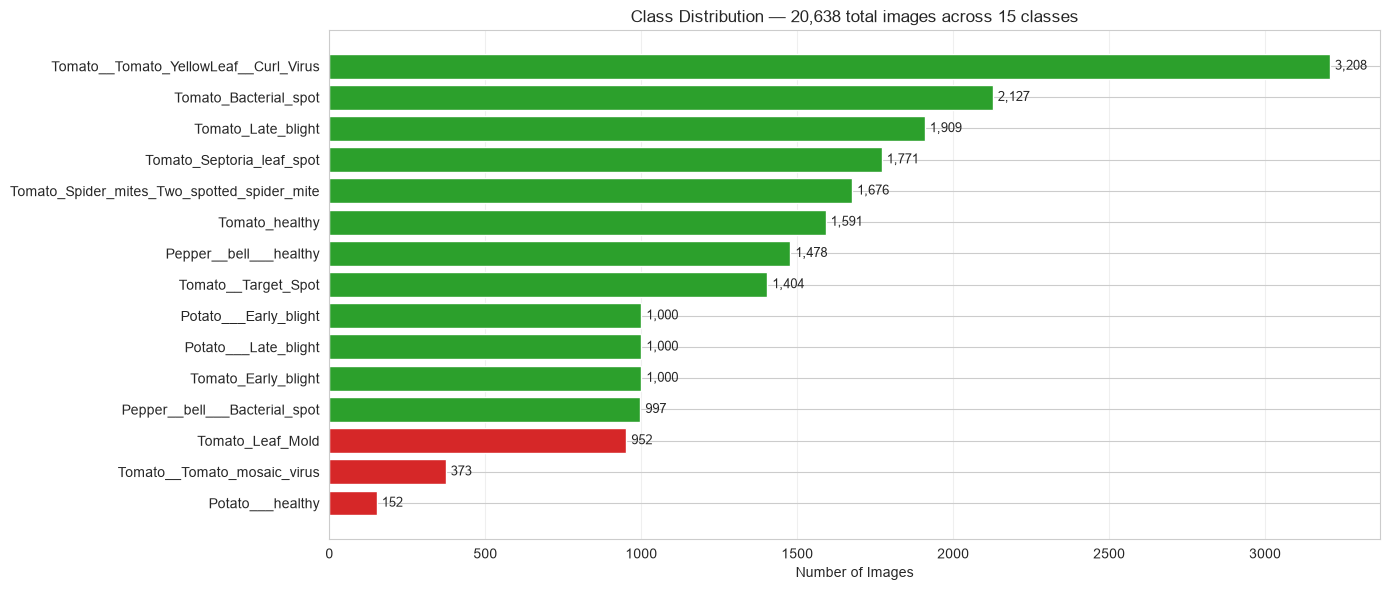

 Red = classes with <30% of the max class count (severely underrepresented)
 Green = reasonably represented classes


In [4]:
fig, ax = plt.subplots(figsize=(14, max(6, len(df) * 0.28)))

# Color by how "balanced" each class is: extreme highs and lows get flagged
max_c = df["count"].max()
colors = ["#d62728" if c < max_c * 0.3 else "#2ca02c" for c in df["count"]]

ax.barh(df["class"], df["count"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Number of Images")
ax.set_title(f"Class Distribution — {df['count'].sum():,} total images across {len(df)} classes")
ax.grid(axis="x", alpha=0.3)

# Annotate counts
for i, (_, row) in enumerate(df.iterrows()):
    ax.text(row["count"] + max_c * 0.005, i, f"{row['count']:,}",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../docs/dataset_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(" Red = classes with <30% of the max class count (severely underrepresented)")
print(" Green = reasonably represented classes")

In [ ]:
POTATO_CLASSES = [c for c in df["class"] if "Potato" in c]
potato_df = df[df["class"].isin(POTATO_CLASSES)].copy()

print("\n🥔 Potato classes only:")
print(potato_df.to_string(index=False))

# Compute imbalance metrics
max_c = potato_df["count"].max()
min_c = potato_df["count"].min()
ratio = max_c / min_c if min_c > 0 else float("inf")

print(f"\n Max class: {max_c}")
print(f" Min class: {min_c}")
print(f" Imbalance ratio (max/min): {ratio:.2f}:1")
print(f" Balance score (min/max):   {min_c / max_c:.3f}  (1.0 = perfectly balanced)")


🥔 Potato classes only:
                class  count
Potato___Early_blight   1000
 Potato___Late_blight   1000
     Potato___healthy    152

📐 Max class: 1000
📐 Min class: 152
📐 Imbalance ratio (max/min): 6.58:1
📐 Balance score (min/max):   0.152  (1.0 = perfectly balanced)


In [6]:
for crop in ["Pepper", "Potato", "Tomato"]:
    sub = df[df["class"].str.startswith(crop)]
    if len(sub) == 0:
        continue
    r = sub["count"].max() / sub["count"].min() if sub["count"].min() > 0 else float("inf")
    print(f"{crop:8s} | classes={len(sub):2d} | total={sub['count'].sum():6,} "
          f"| min={sub['count'].min():5,} | max={sub['count'].max():5,} "
          f"| imbalance={r:.2f}:1")

Pepper   | classes= 2 | total= 2,475 | min=  997 | max=1,478 | imbalance=1.48:1
Potato   | classes= 3 | total= 2,152 | min=  152 | max=1,000 | imbalance=6.58:1
Tomato   | classes=10 | total=16,011 | min=  373 | max=3,208 | imbalance=8.60:1


In [7]:
df.to_csv("../docs/dataset_class_counts.csv", index=False)
print("💾 Saved to ../docs/dataset_class_counts.csv")

💾 Saved to ../docs/dataset_class_counts.csv
